<a href="https://colab.research.google.com/github/salamlakhan7/sprint-03-deep-learning-nlp-transformers/blob/main/Notebooks/CNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Convolutional Neural Networks**

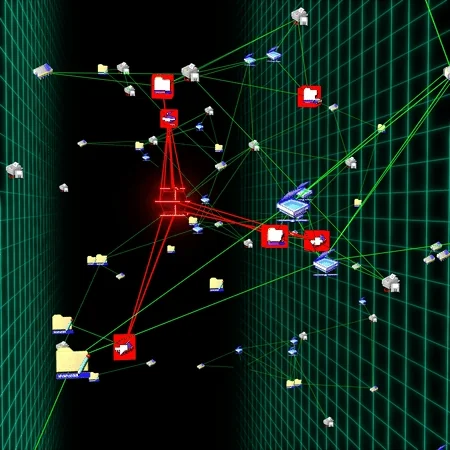

## **Step 1 - Loading the Data (CNN version)**

**Concept:** Same MNIST data as before, but this time we don't flatten it. CNN needs the image to stay in its original 2D shape (28×28) so the convolution filters can actually slide across rows and columns — flattening would destroy the spatial structure CNN exists to exploit.

**Real-life example:** Think of the difference between reading a book page as normal text (spatial layout matters — paragraphs, headings) versus someone reading you every single letter in one long string with no line breaks. Same content, but the second version throws away structure that mattered. ANN forced MNIST into that "one long string." CNN keeps the page intact.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_data   = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.47MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


## **Step 2 - Building the CNN Architecture**

**Concept:** This is where everything from the article becomes real code:

 a Conv layer (detects patterns) → ReLU (non-linearity) → MaxPool (shrinks + keeps key info) → repeat once more for deeper features → Flatten (3D→1D) → Dense (classifier, same as ANN's final layers).

**Real-life example:** Think of the zebra example from the article. First conv+pool pass detects simple things - edges, stripes, curves. A second conv+pool pass combines those into bigger patterns - "these edges form an ear shape," "these stripes form a torso." Only after two passes of increasing abstraction does it flatten everything and hand off to the classifier to make the final call: "this is a zebra." Same idea here, just with digit shapes instead of zebra parts.

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv block 1: detects simple patterns (edges, curves)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        # Conv block 2: detects more complex patterns (combinations of edges)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # Classification part (same role as ANN's layers)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 7 * 7, 128)   # 28 -> 14 -> 7 after two poolings
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)           # final output: 10 digit classes

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()

Quick note on 32*7 *7: MNIST starts at 28×28. Each MaxPool2d(kernel_size=2) halves the size - 28→14 after pool1, 14→7 after pool2. With 32 filters in the last conv layer, the flattened vector length is 32 × 7 × 7 = 1568. This exact calculation is a common source of bugs in CNNs - worth understanding, not just copying.

## **Step 2 Extended - Watching the Shapes Change**

Here's the same model with temporary print() statements added, so you can literally watch the tensor shrink at each stage when you run one batch through it:

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        #print("Input:        ", x.shape)
        x = self.pool1(self.relu1(self.conv1(x)))
        #print("After block 1:", x.shape)
        x = self.pool2(self.relu2(self.conv2(x)))
        #print("After block 2:", x.shape)
        x = self.flatten(x)
        #print("After flatten:", x.shape)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        #print("Final output: ", x.shape)
        return x

model = SimpleCNN()

# Run one batch through it just to see the shapes
sample_images, sample_labels = next(iter(train_loader))
output = model(sample_images)

## **Step 4 - The Training Loop**

**Concept:** Same Input → Model → Prediction → Loss → Learning cycle as the ANN.

 **The only difference:** model(images) now runs the image through conv+pool blocks first instead of flattening immediately - everything else about the loop is identical.

In [8]:
def train_one_epoch():
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

## **Step 5 - Validation Loop**

Identical logic to ANN - no learning, just checking performance.

In [9]:
def validate():
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(val_loader)

## **Step 6 - Running It & Tracking Loss**

In [10]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
for epoch in range(epochs):
    train_loss = train_one_epoch()
    val_loss = validate()
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

Epoch 1: train_loss=0.2054, val_loss=0.0550
Epoch 2: train_loss=0.0539, val_loss=0.0417
Epoch 3: train_loss=0.0380, val_loss=0.0340
Epoch 4: train_loss=0.0287, val_loss=0.0390
Epoch 5: train_loss=0.0216, val_loss=0.0320


## **Step 7 - Accuracy (not just loss)**
Calculated overall correctness on the validation set: 98.92%.

In [11]:
def accuracy():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct / total

print(f"Validation accuracy: {accuracy()*100:.2f}%")

Validation accuracy: 98.92%


## **Step 8 - Predicting on a Custom/Noisy Image**

Built (and fixed) predict_digit() to preprocess and classify an image outside MNIST - first without confidence, then corrected to include softmax-based confidence scoring.

In [14]:
def predict_digit(image_path):
    image = Image.open(image_path).convert('L')

    transform = transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    input_tensor = transform(image)
    input_batch = input_tensor.unsqueeze(0)

    model.eval()
    with torch.no_grad():
        output = model(input_batch)
        probabilities = torch.softmax(output, dim=1)   # converts raw scores to probabilities
        prediction = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities.max().item()

    print(f"Predicted digit: {prediction} (confidence: {confidence*100:.2f}%)")
    return prediction

predict_digit("ANN_test.jfif")

Predicted digit: 3 (confidence: 97.34%)


3

## **Step 9 - Confidence Comparison (ANN vs CNN)**

Ran the same noisy "3" through both models: ANN scored 83.84% confidence, CNN scored 97.34% - same correct prediction, but a real, measurable robustness gap.

That's the real payoff of this whole exercise - laid side by side:


| Model | Prediction | Confidence |
|---|---|---|
| ANN | 3 ✅ | 83.84% |
| CNN | 3 ✅ | **97.34%** |


Both got the right answer, but the CNN was dramatically more *`certain`* - a 13.5-point jump in confidence on the exact same noisy, stardust-covered image. That's not a coincidence or luck; it's the direct, measurable result of what we covered conceptually weeks ago: convolution filters detect local shapes and edges regardless of scattered noise pixels, while the ANN's flatten-everything approach treats every stray white dot as just another number in its 784-value vector, with no way to distinguish "signal" from "noise."


**Full summary, understanding → implementation, now complete:**
- Validation accuracy: 96.59% (ANN) → 98.92% (CNN)
- Noisy-digit confidence: 83.84% (ANN) → 97.34% (CNN)
- Same conclusion, proven twice - once through overall accuracy, once through a real stress test you ran yourself

